# Joint Entropy — Comparação Pré vs Pós Feedback (Ref x Test)

Pipeline atualizado: compara a volta de referência (`DRIVER_REF`/`STINT_REF`) contra
**dois** stints do piloto de teste — `STINT_TEST_PRE` (antes do coaching) e
`STINT_TEST_POST` (depois do coaching) — na pista escolhida em `TRACK`.

Objetivo: quantificar o Δ de melhoria de tempo por setor e correlacioná-lo com
Δ JSD (BrakeRampRate), Δ PE (BrakeRampRate) e Δ MI (Freio×Volante).

In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import entropy, spearmanr
from scipy.spatial.distance import jensenshannon
from scipy.signal import savgol_filter
import antropy as ant

PROJECT_ROOT = Path('..').resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

%load_ext autoreload
%autoreload 2

from config import (TRACK_CONFIGS, DATASETS, DRIVER_ALIAS, resolve_stint_files,
                     IRSDK_AVAILABLE, IBT_CHANNELS, load_stint,
                     basic_clean_and_units, build_lap_validity_table, assign_sectors)

print(f'irsdk available  : {IRSDK_AVAILABLE}')
print(f'Tracks available : {list(TRACK_CONFIGS.keys())}')
print(f'Driver aliases   : {DRIVER_ALIAS}')

irsdk available  : True
Tracks available : ['charlotte_roval_2025', 'summit_point']
Driver aliases   : {'Rodrigo': 'Driver A', 'Tomaz': 'Driver B', 'Morsinaldo': 'Driver C', 'Thallys': 'Driver D'}


## User Selection

Escolha a pista e os stints. `STINT_TEST_PRE`/`STINT_TEST_POST` são as voltas do piloto de teste antes e depois do feedback de coaching.

In [2]:
# =========================
# USER SELECTION
# =========================
TRACK = "charlotte_roval_2025"   # escolha: "charlotte_roval_2025" ou "summit_point"

DRIVER_REF  = "Tomaz"
STINT_REF   = "stint_1"

DRIVER_TEST      = "Morsinaldo"
STINT_TEST_PRE   = "stint_1"     # antes do coaching
STINT_TEST_POST  = "stint_2"     # depois do coaching

BINS = 20  # fixo, não altere (comparabilidade cross-driver / H_max constante)

driver_a = DRIVER_ALIAS.get(DRIVER_REF, DRIVER_REF)
driver_b = DRIVER_ALIAS.get(DRIVER_TEST, DRIVER_TEST)
track_id = TRACK

cfg          = TRACK_CONFIGS[TRACK]
CUSTOM_EDGES = cfg['custom_edges']
SECTOR_NAMES = cfg['sector_names']       # dict {sector_id: nome}
TRACK_NAME   = cfg['track_name']
SECTOR_KEYS  = list(SECTOR_NAMES.keys())

print(f'Track   : {TRACK_NAME}  ({len(SECTOR_KEYS)} setores)')
print(f'Ref     : {driver_a} ({STINT_REF})')
print(f'Test    : {driver_b}  PRE={STINT_TEST_PRE}  POST={STINT_TEST_POST}')

Track   : Charlotte Roval 2025  (18 setores)
Ref     : Driver B (stint_1)
Test    : Driver C  PRE=stint_1  POST=stint_2


In [3]:
# ── Output directory ────────────────────────────────────────
PROJECT_ROOT = Path.home() / "OneDrive/Documents/GitHub/Doutorado/Racing4all"
BASE_IMG_DIR = Path(PROJECT_ROOT) / "Iracing" / "img"
COMPARISON_ID = f"{TRACK}_{driver_a}_vs_{driver_b}_pre_post"
SAVE_DIR = BASE_IMG_DIR / TRACK / COMPARISON_ID
SAVE_DIR.mkdir(parents=True, exist_ok=True)
print(f"Output directory: {SAVE_DIR}")

Output directory: C:\Users\to_fi\OneDrive\Documents\GitHub\Doutorado\Racing4all\Iracing\img\charlotte_roval_2025\charlotte_roval_2025_Driver B_vs_Driver C_pre_post


## Funções utilitárias de carga/limpeza

Generaliza o carregamento para qualquer (driver, stint), evitando duplicar código para PRE e POST.

In [4]:
def format_laptime(seconds: float) -> str:
    if pd.isna(seconds):
        return "N/A"
    minutes = int(seconds // 60)
    remaining_seconds = seconds % 60
    return f"{minutes:02d}:{remaining_seconds:06.3f}"


def load_stint_clean(track, driver, stint, max_lap_time_s=115.0):
    """Carrega, limpa e filtra apenas voltas válidas para um (driver, stint)."""
    files = [str(p) for p in resolve_stint_files(track, driver, stint)]
    raw_df = load_stint(files)
    df = basic_clean_and_units(raw_df)

    laps = build_lap_validity_table(df, max_lap_time_s=max_lap_time_s)
    laps['LapTime_Formatted'] = laps['LapTime_s'].apply(format_laptime)

    valid_laps = laps[laps['Valid']]['Lap']
    df_clean = df[df['Lap'].isin(valid_laps)].copy()
    df_clean.sort_values(['Lap', 'SessionTime'], inplace=True)
    df_clean['LocalLapTime'] = df_clean.groupby('Lap')['SessionTime'].transform(lambda x: x - x.min())

    if 'TotalAccel_G' not in df_clean.columns:
        df_clean['TotalAccel_G'] = np.sqrt((df_clean['LatAccel'] / 9.81) ** 2 +
                                            (df_clean['LongAccel'] / 9.81) ** 2)
    return df_clean, laps


def best_lap_df(df_clean, laps):
    """Retorna o DataFrame filtrado apenas para a volta mais rápida válida."""
    valid = laps[laps['Valid']]
    best_lap = valid.loc[valid['LapTime_s'].idxmin(), 'Lap']
    return df_clean[df_clean['Lap'] == best_lap].copy(), int(best_lap)

## Carregamento: Referência, Pré e Pós

In [5]:
df_ref_clean,  laps_ref  = load_stint_clean(TRACK, DRIVER_REF,  STINT_REF)
df_pre_clean,  laps_pre  = load_stint_clean(TRACK, DRIVER_TEST, STINT_TEST_PRE)
df_post_clean, laps_post = load_stint_clean(TRACK, DRIVER_TEST, STINT_TEST_POST)

df_ref_best,  lap_ref_best  = best_lap_df(df_ref_clean,  laps_ref)
df_pre_best,  lap_pre_best  = best_lap_df(df_pre_clean,  laps_pre)
df_post_best, lap_post_best = best_lap_df(df_post_clean, laps_post)

print(f"{driver_a} (ref)  — melhor volta: {lap_ref_best}  ({format_laptime(laps_ref.set_index('Lap').loc[lap_ref_best,'LapTime_s'])})")
print(f"{driver_b} (pre)  — melhor volta: {lap_pre_best}  ({format_laptime(laps_pre.set_index('Lap').loc[lap_pre_best,'LapTime_s'])})")
print(f"{driver_b} (post) — melhor volta: {lap_post_best}  ({format_laptime(laps_post.set_index('Lap').loc[lap_post_best,'LapTime_s'])})")

df_ref_sec  = assign_sectors(df_ref_best,  CUSTOM_EDGES)
df_pre_sec  = assign_sectors(df_pre_best,  CUSTOM_EDGES)
df_post_sec = assign_sectors(df_post_best, CUSTOM_EDGES)

    [1/1] Loading mx5 mx52016_charlotte 2025 roval2025 2025-11-26 13-56-41.ibt … OK (179,705 samples, laps 0–28)
──────────────────────────────────────────────────────────────
  Lap Validity Report  (29 laps total)
──────────────────────────────────────────────────────────────
  ✅ Valid   : 25 laps
  🏆 Fastest : Lap 19  (01:36.733)
  ❌ Invalid : 4 laps
     Lap   0  48:37.467  → FracLowSpeed=0.30 | LapTime=2917.5s | GPS=95.0%<100%
     Lap   5  01:40.250  → IQR_outlier
     Lap  10  01:48.733  → IQR_outlier
     Lap  28  02:57.883  → FracLowSpeed=0.44 | LapTime=177.9s
──────────────────────────────────────────────────────────────
    [1/1] Loading mx5 mx52016_charlotte 2025 roval2025 2026-01-27 16-13-55(Morsinaldo).ibt … OK (121,637 samples, laps 7–26)
──────────────────────────────────────────────────────────────
  Lap Validity Report  (20 laps total)
──────────────────────────────────────────────────────────────
  ✅ Valid   : 11 laps
  🏆 Fastest : Lap 21  (01:39.000)
  ❌ Invalid : 9 

## Ranges globais (Brake_Pct / SteeringWheelAngle)

Mesma lógica de bins fixos usada no restante do pipeline — calculada a partir de todos os stints disponíveis na pista escolhida.

In [6]:
def compute_global_ranges(datasets, variables, track_filter=None, lower_pct=1, upper_pct=99):
    col_values = {col: [] for col, _ in variables}
    for track_key, track_info in datasets.items():
        if track_filter is not None and track_key != track_filter:
            continue
        base_path = Path(track_info["base_path"])
        for pilot, stints in track_info["sessions"].items():
            for stint_key, filenames in stints.items():
                if isinstance(filenames, str):
                    filenames = [filenames]
                filepaths = [base_path / f for f in filenames]
                try:
                    df_raw = load_stint(filepaths)
                    if df_raw.empty:
                        continue
                    df_tmp = basic_clean_and_units(df_raw)
                    if 'TotalAccel_G' not in df_tmp.columns:
                        df_tmp['TotalAccel_G'] = np.sqrt((df_tmp['LatAccel'] / 9.81) ** 2 +
                                                          (df_tmp['LongAccel'] / 9.81) ** 2)
                    for col, _ in variables:
                        if col in df_tmp.columns:
                            col_values[col].append(df_tmp[col].dropna().values)
                except Exception as e:
                    print(f"  ⚠️ {track_key} | {pilot} | {stint_key} — {e}")

    ranges = {}
    for col, _ in variables:
        if col_values[col]:
            all_vals = np.concatenate(col_values[col])
            ranges[col] = (np.percentile(all_vals, lower_pct), np.percentile(all_vals, upper_pct))
    return ranges


variaveis_entropia = [
    ('Brake_Pct', 'Brake'),
    ('SteeringWheelAngle', 'Steering Angle'),
]

global_ranges = compute_global_ranges(DATASETS, variaveis_entropia, track_filter=TRACK)
brake_range = global_ranges.get('Brake_Pct', (0, 100))
steer_range = global_ranges.get('SteeringWheelAngle', (-180, 180))
print(f"Brake range : {brake_range}")
print(f"Steer range : {steer_range}")

    [1/1] Loading mx5 mx52016_charlotte 2025 roval2025 2025-11-26 13-56-41.ibt … OK (179,705 samples, laps 0–28)
    [1/2] Loading mx5 mx52016_charlotte 2025 roval2025 2026-03-01 17-16-27.ibt … OK (100,476 samples, laps 0–16)
    [2/2] Loading mx5 mx52016_charlotte 2025 roval2025 2026-03-01 16-20-04.ibt … OK (148,787 samples, laps 17–40)
    [1/1] Loading mx5 mx52016_charlotte 2025 roval2025 2026-05-11 22-43-15.ibt … OK (64,277 samples, laps 0–9)
    [1/1] Loading mx5 mx52016_charlotte 2025 roval2025 2026-05-11 23-11-08.ibt … OK (55,207 samples, laps 0–9)
    [1/1] Loading mx5 mx52016_charlotte 2025 roval2025 2026-01-27 16-13-55(Morsinaldo).ibt … OK (121,637 samples, laps 7–26)
    [1/1] Loading mx5 mx52016_charlotte 2025 roval2025 2026-01-28 15-24-41(Morsinaldo).ibt … OK (111,960 samples, laps 0–31)
    [1/1] Loading mx5 mx52016_charlotte 2025 roval2025 2026-02-08 15-06-22(Rodrigo).ibt … OK (274,948 samples, laps 0–49)
    [1/1] Loading mx5 mx52016_charlotte 2025 roval2025 2026-07-01 

## Métricas: JSD, Permutation Entropy e Informação Mútua

- **JSD (BrakeRampRate)**: divergência de *forma* entre a taxa de variação do freio do
  piloto de teste e a referência, bins fixos (`BINS`), `scipy.stats.entropy`/`jensenshannon`, base 2.
- **PE (BrakeRampRate)**: Permutation Entropy (`antropy`, m=3, τ=1) — previsibilidade da modulação.
- **MI (Freio×Volante)**: Informação Mútua via entropia conjunta, mesmo par de canais do
  `compute_joint_entropy_brake_steer` original.

In [7]:
def compute_brake_ramp_rate_df(df, brake_col="Brake_Pct", time_col="SessionTime"):
    d = df.sort_values(time_col)
    brake = d[brake_col].to_numpy()
    t_rel = d[time_col].to_numpy()
    dt = np.mean(np.diff(t_rel)) if len(t_rel) > 1 else 0.01
    rate = np.gradient(brake, dt)
    window = min(9, len(rate))
    if window > 3 and window % 2 != 0:
        rate = savgol_filter(rate, window, 3)
    return rate


def jsd_fixed_bins(x, y, bins=BINS):
    lo = min(np.nanmin(x), np.nanmin(y))
    hi = max(np.nanmax(x), np.nanmax(y))
    edges = np.linspace(lo, hi, bins + 1)
    p, _ = np.histogram(x, bins=edges, density=False)
    q, _ = np.histogram(y, bins=edges, density=False)
    p = p / p.sum()
    q = q / q.sum()
    dist = jensenshannon(p, q, base=2)
    return float(dist ** 2)


def pe_from_series(x, m=3, delay=1):
    return float(ant.perm_entropy(x, order=m, delay=delay, normalize=True))


def compute_joint_entropy_brake_steer(df, brake_range, steer_range, bins=BINS):
    brake = df['Brake_Pct'].dropna().values
    steer = df['SteeringWheelAngle'].dropna().values
    n = min(len(brake), len(steer))
    brake, steer = brake[:n], steer[:n]

    hist2d, _, _ = np.histogram2d(brake, steer, bins=bins, range=[brake_range, steer_range], density=True)
    p_joint = hist2d / hist2d.sum()
    h_joint = entropy(p_joint.flatten() + 1e-10, base=2)

    counts_b, _ = np.histogram(brake, bins=bins, range=brake_range, density=True)
    counts_s, _ = np.histogram(steer, bins=bins, range=steer_range, density=True)
    h_b = entropy(counts_b + 1e-10, base=2)
    h_s = entropy(counts_s + 1e-10, base=2)
    mi = h_b + h_s - h_joint
    return h_joint, h_b, h_s, mi


def compute_sector_delta_time(df_a_sec, df_b_sec, sector_keys):
    """DeltaTime_s = tempo(B) - tempo(A) por setor."""
    rows = []
    for sector in sector_keys:
        ta = df_a_sec[df_a_sec['Sector'] == sector]['SessionTime']
        tb = df_b_sec[df_b_sec['Sector'] == sector]['SessionTime']
        if ta.empty or tb.empty:
            continue
        rows.append({
            'Sector': sector,
            'SectorTime_A': ta.max() - ta.min(),
            'SectorTime_B': tb.max() - tb.min(),
            'DeltaTime_s': (tb.max() - tb.min()) - (ta.max() - ta.min())
        })
    return pd.DataFrame(rows)


def sector_metrics_vs_ref(df_ref_sec, df_test_sec, sector_keys, brake_range, steer_range,
                           bins=BINS, min_samples=10):
    """Para cada setor: JSD/PE (test vs ref) do BrakeRampRate + MI(Freio,Volante) do próprio teste."""
    rows = []
    for sector in sector_keys:
        sub_ref  = df_ref_sec[df_ref_sec['Sector'] == sector]
        sub_test = df_test_sec[df_test_sec['Sector'] == sector]
        if len(sub_ref) < min_samples or len(sub_test) < min_samples:
            continue

        rate_ref  = compute_brake_ramp_rate_df(sub_ref)
        rate_test = compute_brake_ramp_rate_df(sub_test)

        jsd_val = jsd_fixed_bins(rate_ref, rate_test, bins=bins)
        pe_ref  = pe_from_series(rate_ref)
        pe_test = pe_from_series(rate_test)

        _, _, _, mi_test = compute_joint_entropy_brake_steer(sub_test, brake_range, steer_range, bins=bins)

        rows.append({
            'Sector': sector,
            'JSD_BrakeRampRate': jsd_val,
            'PE_ref': pe_ref,
            'PE_test': pe_test,
            'MI_test': mi_test,
            'BrakePeak_ref': float(sub_ref['Brake_Pct'].max()),
            'BrakePeak_test': float(sub_test['Brake_Pct'].max()),
        })
    return pd.DataFrame(rows)

## Cálculo por setor: Pré e Pós

In [8]:
dt_pre  = compute_sector_delta_time(df_ref_sec, df_pre_sec,  SECTOR_KEYS)
dt_post = compute_sector_delta_time(df_ref_sec, df_post_sec, SECTOR_KEYS)

m_pre  = sector_metrics_vs_ref(df_ref_sec, df_pre_sec,  SECTOR_KEYS, brake_range, steer_range)
m_post = sector_metrics_vs_ref(df_ref_sec, df_post_sec, SECTOR_KEYS, brake_range, steer_range)

display(dt_pre.head())
display(m_pre.head())

,Sector,SectorTime_A,SectorTime_B,DeltaTime_s
0,1,4.316667,4.466667,0.150000
1,2,6.083333,6.300000,0.216667
2,3,4.450000,4.533333,0.083333
3,4,5.066667,5.183333,0.116667
4,5,7.616667,7.966667,0.350000


,Sector,JSD_BrakeRampRate,PE_ref,PE_test,MI_test,BrakePeak_ref,BrakePeak_test
0,1,0.110285,0.274492,0.000000,-1.025332e-06,39.977127,0.000000
1,2,0.036624,0.198356,0.130733,-9.398270e-07,5.425173,1.612087
2,3,0.113290,0.315766,0.000000,-9.492617e-07,31.453872,0.000000
3,4,0.085563,0.320615,0.515533,5.593846e-01,14.176866,33.435288
4,5,0.000000,0.000000,0.000000,-9.388159e-07,0.000000,0.000000


## Tabela mestre: Δ de melhoria por setor

- `Time_Improvement_s` = `DeltaTime_pre - DeltaTime_post` → **positivo = melhora** (perdeu menos tempo em relação à referência depois do feedback).
- `Delta_JSD` = `JSD_pre - JSD_post` → **positivo = aproximação** da forma de modulação do freio em relação à referência.
- `Delta_PE`  = `PE_test_post - PE_test_pre` (convenção post − pre) → negativo = ficou mais previsível/consistente.
- `Delta_MI`  = `MI_test_post - MI_test_pre` → positivo = mais coordenação freio×volante após o feedback.

In [9]:
merged = m_pre.merge(m_post, on='Sector', suffixes=('_pre', '_post'))
merged = merged.merge(dt_pre[['Sector', 'DeltaTime_s']].rename(columns={'DeltaTime_s': 'DeltaTime_pre'}), on='Sector')
merged = merged.merge(dt_post[['Sector', 'DeltaTime_s']].rename(columns={'DeltaTime_s': 'DeltaTime_post'}), on='Sector')

merged['Time_Improvement_s'] = merged['DeltaTime_pre'] - merged['DeltaTime_post']
merged['Delta_JSD'] = merged['JSD_BrakeRampRate_pre'] - merged['JSD_BrakeRampRate_post']
merged['Delta_PE']  = merged['PE_test_post'] - merged['PE_test_pre']
merged['Delta_MI']  = merged['MI_test_post'] - merged['MI_test_pre']
merged['Turn'] = merged['Sector'].map(SECTOR_NAMES)

merged = merged.sort_values('Time_Improvement_s', ascending=False).reset_index(drop=True)
display(merged[['Sector', 'Turn', 'DeltaTime_pre', 'DeltaTime_post', 'Time_Improvement_s',
                 'Delta_JSD', 'Delta_PE', 'Delta_MI']])

,Sector,Turn,DeltaTime_pre,DeltaTime_post,Time_Improvement_s,Delta_JSD,Delta_PE,Delta_MI
0,5,T5/T6 Transition,3.500000e-01,-0.133333,0.483333,0.000000,0.000000,-3.150641e-08
1,17,Final Chicane Exit,3.833333e-01,0.100000,0.283333,0.000000,0.000000,-1.073420e-08
2,16,Final Chicane Entry,1.500000e-01,-0.066667,0.216667,0.029114,-0.063113,-8.968163e-02
3,8,Oval Turn 1,6.666667e-02,-0.116667,0.183333,0.000000,0.000000,1.026935e-08
4,11,Bus Stop Entry,2.166667e-01,0.116667,0.100000,-0.050057,-0.228532,1.846927e-01
5,1,T1 (Heartlands),1.500000e-01,0.050000,0.100000,-0.000567,0.426879,1.796563e-01
6,3,T3 (Infield),8.333333e-02,0.016667,0.066667,0.066414,0.324633,3.623155e-01
7,10,Backstretch,1.666667e-02,-0.016667,0.033333,0.000000,0.000000,5.087641e-10
8,4,T4,1.166667e-01,0.083333,0.033333,0.053659,-0.078744,-2.800663e-01
9,9,Oval Turn 2,-1.666667e-02,-0.033333,0.016667,0.000000,0.000000,-1.010914e-08


## Correlação: melhoria de tempo x métricas de entropia

Spearman (não-paramétrico), apropriado dado o N pequeno de setores. Reporta ρ e p para
cada métrica candidata a explicar a melhoria de tempo.

In [10]:
print(f"Correlação de Spearman — Time_Improvement_s vs métricas ({TRACK_NAME}, {driver_b})\n")
for col in ['Delta_JSD', 'Delta_PE', 'Delta_MI']:
    valid = merged.dropna(subset=['Time_Improvement_s', col])
    if len(valid) >= 4:
        r, p = spearmanr(valid['Time_Improvement_s'], valid[col])
        sig = "significativo (p<0.05)" if p < 0.05 else "não significativo"
        print(f"  {col:12s} -> rho={r:+.3f}  p={p:.3f}  n={len(valid)}  [{sig}]")
    else:
        print(f"  {col:12s} -> dados insuficientes (n={len(valid)})")

Correlação de Spearman — Time_Improvement_s vs métricas (Charlotte Roval 2025, Driver C)

  Delta_JSD    -> rho=+0.135  p=0.594  n=18  [não significativo]
  Delta_PE     -> rho=-0.057  p=0.821  n=18  [não significativo]
  Delta_MI     -> rho=-0.127  p=0.615  n=18  [não significativo]


## Dashboard 1 — Pré vs Pós por setor (Δtempo, ΔJSD, ΔPE, ΔMI)

Saved: pre_post_dashboard_Driver B_vs_Driver C_charlotte_roval_2025.png


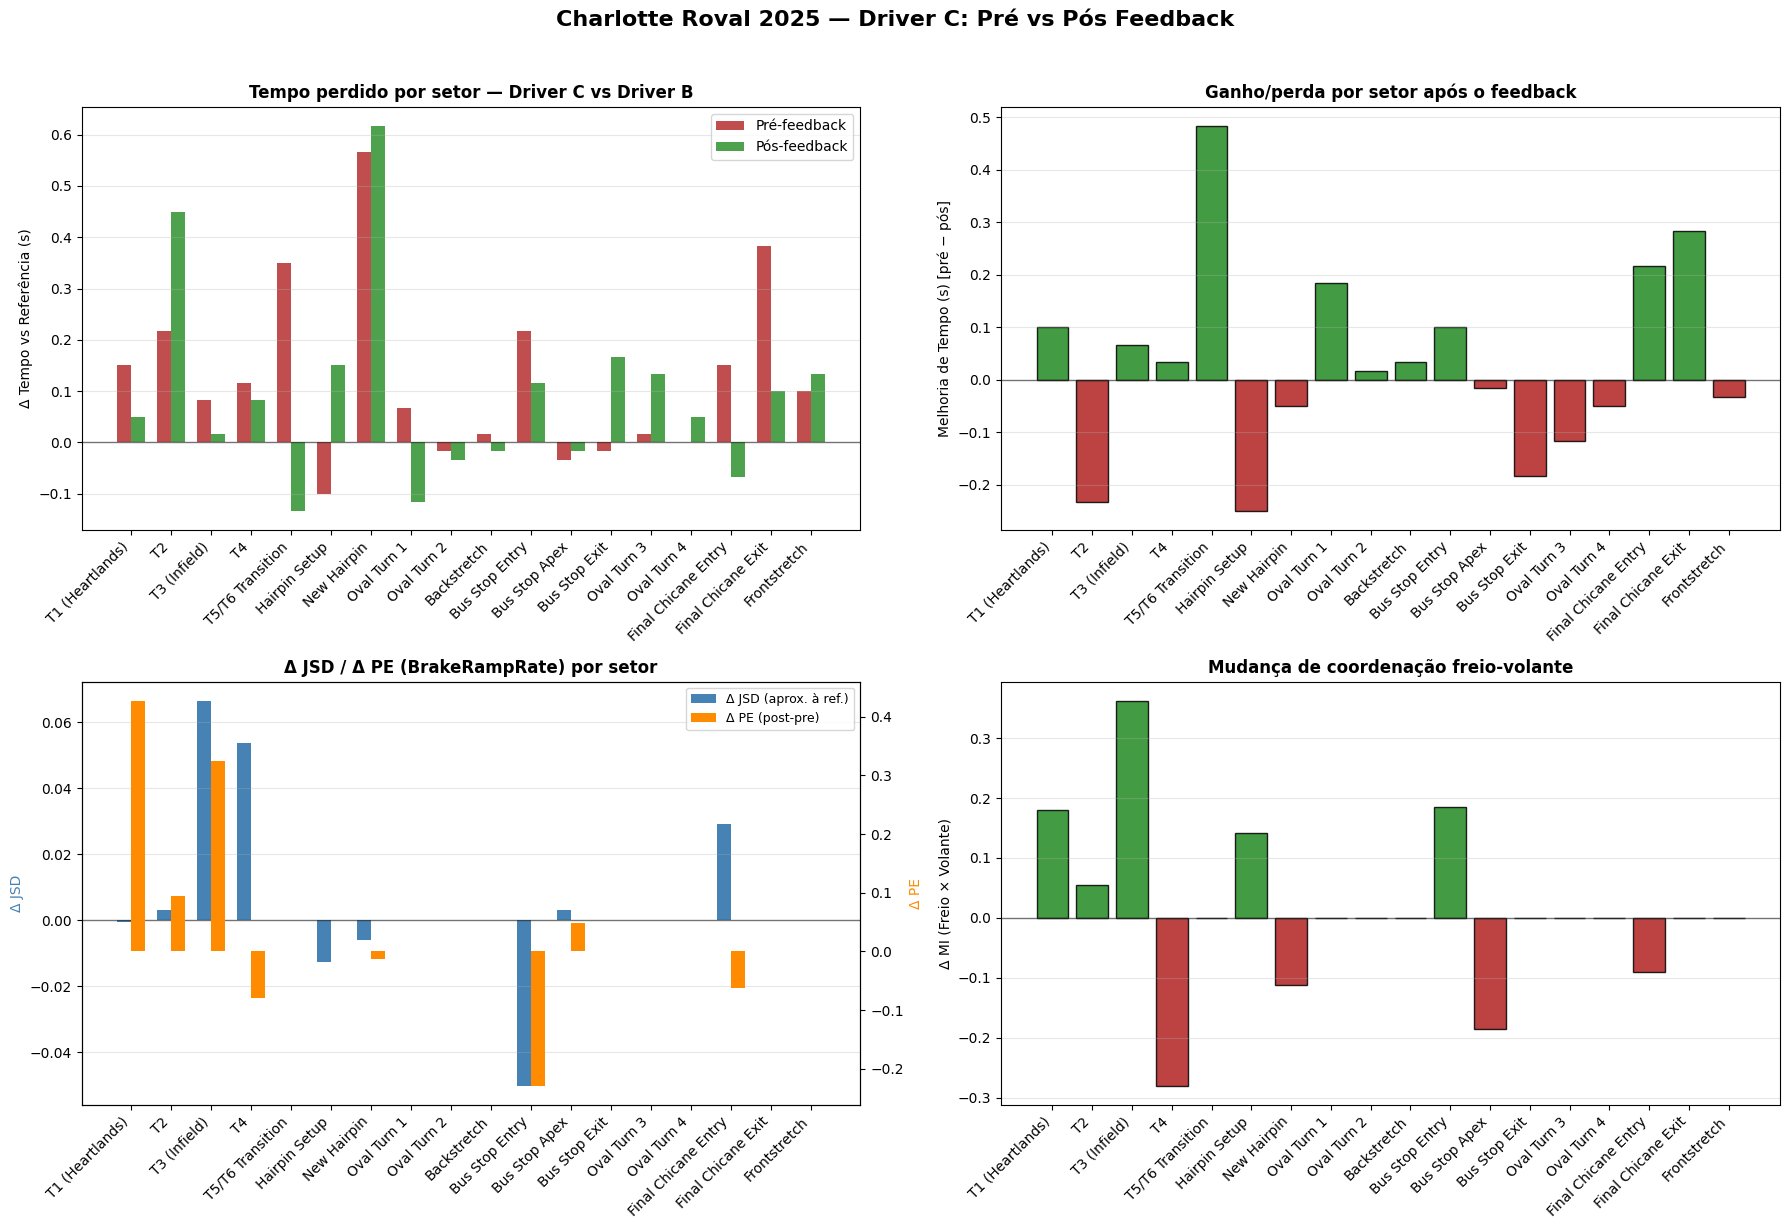

In [11]:
def plot_pre_post_dashboard(df, driver_a, driver_b, track_name, save_dir=None):
    d = df.sort_values('Sector').reset_index(drop=True)
    x = np.arange(len(d))

    fig, axes = plt.subplots(2, 2, figsize=(18, 12))

    # --- (0,0) Tempo perdido: pre vs post ---
    ax = axes[0, 0]
    w = 0.35
    ax.bar(x - w/2, d['DeltaTime_pre'],  w, label='Pré-feedback',  color='firebrick', alpha=0.8)
    ax.bar(x + w/2, d['DeltaTime_post'], w, label='Pós-feedback', color='forestgreen', alpha=0.8)
    ax.axhline(0, color='black', linewidth=1, alpha=0.5)
    ax.set_xticks(x); ax.set_xticklabels(d['Turn'], rotation=45, ha='right')
    ax.set_ylabel('Δ Tempo vs Referência (s)')
    ax.set_title(f'Tempo perdido por setor — {driver_b} vs {driver_a}', fontweight='bold')
    ax.legend(); ax.grid(True, axis='y', alpha=0.3)

    # --- (0,1) Time_Improvement por setor ---
    ax = axes[0, 1]
    colors = ['forestgreen' if v > 0 else 'firebrick' for v in d['Time_Improvement_s']]
    ax.bar(x, d['Time_Improvement_s'], color=colors, edgecolor='black', alpha=0.85)
    ax.axhline(0, color='black', linewidth=1, alpha=0.5)
    ax.set_xticks(x); ax.set_xticklabels(d['Turn'], rotation=45, ha='right')
    ax.set_ylabel('Melhoria de Tempo (s) [pré − pós]')
    ax.set_title('Ganho/perda por setor após o feedback', fontweight='bold')
    ax.grid(True, axis='y', alpha=0.3)

    # --- (1,0) Delta_JSD e Delta_PE por setor ---
    ax = axes[1, 0]
    ax2 = ax.twinx()
    ax.bar(x - w/2, d['Delta_JSD'], w, color='steelblue', label='Δ JSD (aprox. à ref.)')
    ax2.bar(x + w/2, d['Delta_PE'], w, color='darkorange', label='Δ PE (post-pre)')
    ax.axhline(0, color='black', linewidth=1, alpha=0.5)
    ax.set_xticks(x); ax.set_xticklabels(d['Turn'], rotation=45, ha='right')
    ax.set_ylabel('Δ JSD', color='steelblue')
    ax2.set_ylabel('Δ PE', color='darkorange')
    ax.set_title('Δ JSD / Δ PE (BrakeRampRate) por setor', fontweight='bold')
    l1, la1 = ax.get_legend_handles_labels(); l2, la2 = ax2.get_legend_handles_labels()
    ax.legend(l1 + l2, la1 + la2, loc='upper right', fontsize=9)
    ax.grid(True, axis='y', alpha=0.3)

    # --- (1,1) Delta_MI por setor ---
    ax = axes[1, 1]
    colors_mi = ['forestgreen' if v > 0 else 'firebrick' for v in d['Delta_MI']]
    ax.bar(x, d['Delta_MI'], color=colors_mi, edgecolor='black', alpha=0.85)
    ax.axhline(0, color='black', linewidth=1, alpha=0.5)
    ax.set_xticks(x); ax.set_xticklabels(d['Turn'], rotation=45, ha='right')
    ax.set_ylabel('Δ MI (Freio × Volante)')
    ax.set_title('Mudança de coordenação freio-volante', fontweight='bold')
    ax.grid(True, axis='y', alpha=0.3)

    plt.suptitle(f'{track_name} — {driver_b}: Pré vs Pós Feedback', fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()

    if save_dir is not None:
        fname = f"pre_post_dashboard_{driver_a}_vs_{driver_b}_{track_id}.png"
        fig.savefig(Path(save_dir) / fname, dpi=300, bbox_inches='tight')
        print(f"Saved: {fname}")
    plt.show()


plot_pre_post_dashboard(merged, driver_a, driver_b, TRACK_NAME, save_dir=SAVE_DIR)

## Dashboard 2 — Scatter: melhoria de tempo x métricas de entropia

Cada ponto é um setor. Reta de referência y=0 e rótulo do ρ de Spearman em cada painel.

Saved: improvement_correlation_Driver B_vs_Driver C_charlotte_roval_2025.png


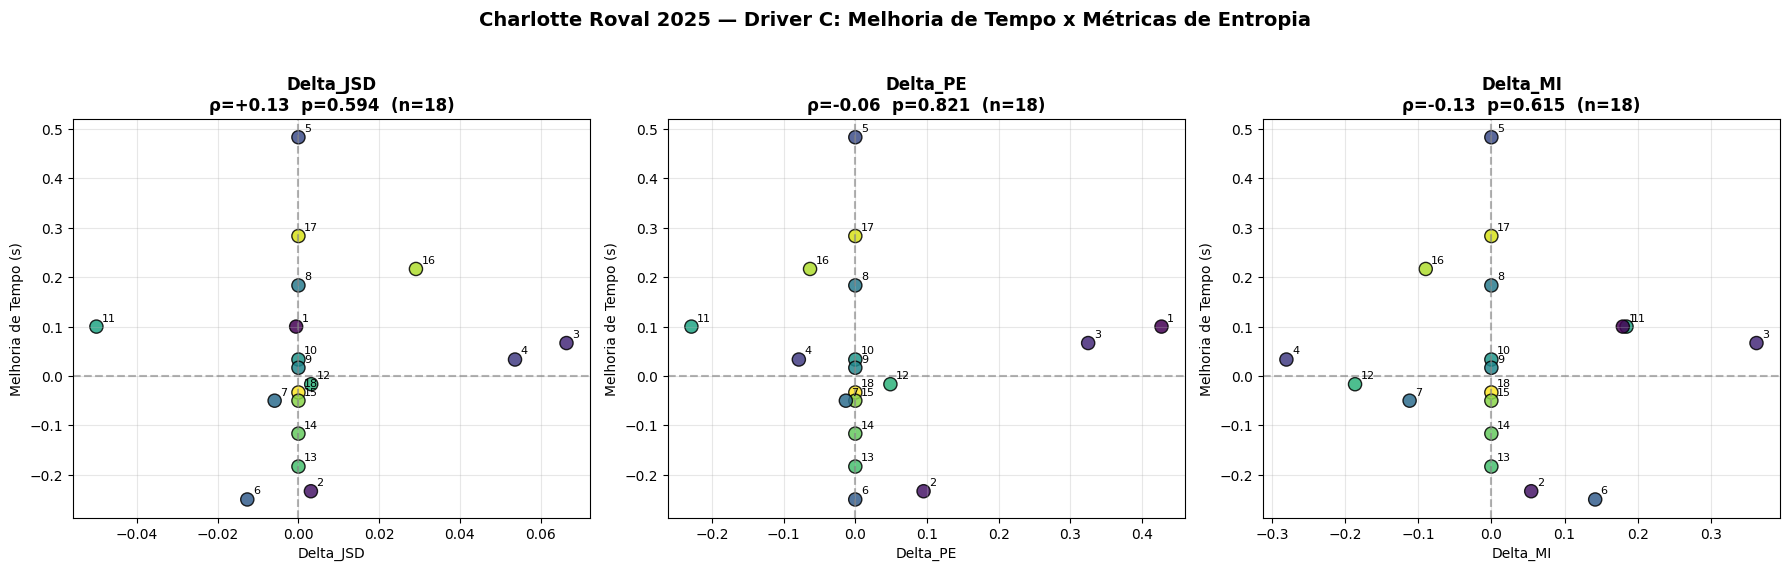

In [12]:
def plot_improvement_correlation(df, metric_cols, driver_a, driver_b, track_name, save_dir=None):
    fig, axes = plt.subplots(1, len(metric_cols), figsize=(6 * len(metric_cols), 5.5))
    if len(metric_cols) == 1:
        axes = [axes]

    for ax, col in zip(axes, metric_cols):
        valid = df.dropna(subset=['Time_Improvement_s', col])
        sc = ax.scatter(valid[col], valid['Time_Improvement_s'],
                         c=valid['Sector'], cmap='viridis', s=90, edgecolor='black', alpha=0.85)
        for _, row in valid.iterrows():
            ax.annotate(str(row['Sector']), (row[col], row['Time_Improvement_s']),
                        fontsize=8, xytext=(4, 4), textcoords='offset points')

        ax.axhline(0, color='gray', linestyle='--', alpha=0.6)
        ax.axvline(0, color='gray', linestyle='--', alpha=0.6)

        if len(valid) >= 4:
            r, p = spearmanr(valid[col], valid['Time_Improvement_s'])
            ax.set_title(f'{col}\nρ={r:+.2f}  p={p:.3f}  (n={len(valid)})', fontweight='bold')
        else:
            ax.set_title(col, fontweight='bold')

        ax.set_xlabel(col)
        ax.set_ylabel('Melhoria de Tempo (s)')
        ax.grid(True, alpha=0.3)

    plt.suptitle(f'{track_name} — {driver_b}: Melhoria de Tempo x Métricas de Entropia',
                 fontsize=14, fontweight='bold', y=1.03)
    plt.tight_layout()

    if save_dir is not None:
        fname = f"improvement_correlation_{driver_a}_vs_{driver_b}_{track_id}.png"
        fig.savefig(Path(save_dir) / fname, dpi=300, bbox_inches='tight')
        print(f"Saved: {fname}")
    plt.show()


plot_improvement_correlation(merged, ['Delta_JSD', 'Delta_PE', 'Delta_MI'],
                              driver_a, driver_b, TRACK_NAME, save_dir=SAVE_DIR)

## Notas de uso

- Troque `TRACK`, `DRIVER_REF`/`STINT_REF` e `DRIVER_TEST`/`STINT_TEST_PRE`/`STINT_TEST_POST`
  na célula de **User Selection** para rodar outra combinação pista/piloto/stints.
- `BINS=20`, PE com `m=3, τ=1` e JSD em base 2 seguem os parâmetros fixos do restante do artigo — não altere.
- Se `n` nas correlações for muito pequeno (poucos setores com amostra suficiente),
  considere relaxar `min_samples` em `sector_metrics_vs_ref`, mas documente isso no artigo.
- Esta análise usa a **melhor volta** de cada stint (pré e pós); se preferir usar a
  média de todas as voltas válidas do stint, adapte `best_lap_df` para agregar por setor
  em vez de selecionar uma única volta.